# 12 — Transaction Cost Deep Dive

## Purpose

Detailed TC analysis for the selected strategy: **All6-EW + TO\_MVO** (EEM-hedged).

- Dynamic country-weighted TC from actual holdings
- Time-varying TC (secular decline in EM trading costs)
- TC decomposition: commission, spread, market impact
- Turnover decomposition: stock selection vs industry allocation
- Gradual Sharpe loss under varying TC levels
- Break-even TC analysis

**Note:** Country-level TC estimates from Domowitz, Glen & Madhavan (2001).
These likely overestimate current (2024) costs. Actual TC may be 20-30% lower,
but we use conservative estimates for robustness.

In [1]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_signal_data, COUNTRY_TC_BPS, DEFAULT_TC_BPS, FACTOR_COLUMNS, INDUSTRIES

OUTPUT_DIR = '../output'
HOLD_START = pd.Timestamp('2019-01-01')

def ann_sharpe(s):
    s = s.dropna()
    if len(s) < 6 or s.std() == 0: return np.nan
    return s.mean()*12 / (s.std()*np.sqrt(12))

def max_dd(s):
    cum = (1 + s.dropna()).cumprod()
    return float((cum / cum.cummax() - 1).min())

df = load_signal_data('../data')
df = df.sort_values(['ym', 'ric'])

hdf = pd.read_csv(f'{OUTPUT_DIR}/csv/nb09_hedged_returns.csv', index_col=0, parse_dates=True)

print(f'Signal data: {len(df)} rows, {df["ym"].nunique()} months')
print(f'Countries: {df["country"].nunique()}')

  Dropped 12 duplicate (ric, ym) rows
Signal data loaded: 98,742 rows x 51 cols | 2004-01 to 2025-03
Signal data: 98742 rows, 255 months
Countries: 36


## 1. Reconstruct Holdings from Factor Portfolios

In [2]:
from scipy.stats import rankdata

ret_col = 'mret_bbg'
df_oos = df[df['ym'] >= '2009-02'].copy()

all_holdings = []
for ym in sorted(df_oos['ym'].unique()):
    month_df = df_oos[df_oos['ym'] == ym].copy()
    for ind in INDUSTRIES:
        ind_df = month_df[month_df['industry'] == ind].copy()
        if len(ind_df) < 5:
            continue
        
        # All6-EW composite: equal-weight all 6 factors
        valid_factors = [f for f in FACTOR_COLUMNS if ind_df[f].notna().sum() >= 5]
        if len(valid_factors) == 0:
            continue
        
        for f in valid_factors:
            ind_df[f'{f}_rank'] = rankdata(ind_df[f].fillna(ind_df[f].median()))
        
        ind_df['composite_score'] = sum(ind_df[f'{f}_rank'] for f in valid_factors) / len(valid_factors)
        
        # Top quintile (or tercile if small)
        n = len(ind_df)
        top_frac = 0.2 if n >= 15 else 0.33
        cutoff = ind_df['composite_score'].quantile(1 - top_frac)
        selected = ind_df[ind_df['composite_score'] >= cutoff].copy()
        
        if len(selected) == 0:
            continue
        
        selected['weight'] = 1.0 / (len(selected) * len(INDUSTRIES))
        selected['holding_industry'] = ind
        
        for _, row in selected.iterrows():
            all_holdings.append({
                'ym': ym,
                'ric': row['ric'],
                'country': row.get('country', 'Unknown'),
                'industry': ind,
                'weight': selected['weight'].iloc[0],
                ret_col: row.get(ret_col, np.nan),
            })

holdings = pd.DataFrame(all_holdings)
holdings['tc_bps'] = holdings['country'].map(COUNTRY_TC_BPS).fillna(DEFAULT_TC_BPS)

oos = holdings[holdings['ym'] >= HOLD_START.strftime('%Y-%m')].copy()
print(f'Total holdings: {len(holdings)} stock-months')
print(f'Holdout holdings: {len(oos)} stock-months, {oos["ym"].nunique()} months')
print(f'Avg stocks per month: {len(oos)/oos["ym"].nunique():.0f}')
print(f'Countries in holdout: {oos["country"].nunique()}')

Total holdings: 17754 stock-months
Holdout holdings: 7499 stock-months, 75 months
Avg stocks per month: 100
Countries in holdout: 27


## 2. Dynamic Country-Weighted TC

=== Dynamic Country-Weighted TC (bps) ===
Holdings-weighted: mean=48.0, median=48.1, min=45.7, max=50.2
Universe average (simple): 55 bps

=== Country TC Contribution (Strategy Holdings) ===
Country                         Avg Wt% TC (bps) TC Contrib Months
----------------------------------------------------------------------
HONG KONG                        1.76%       20       0.00     57
CZECH REPUBLIC                   1.69%       45       0.01     31
THAILAND                         1.65%       45       0.01     75
COLOMBIA                         1.44%       60       0.01     57
MALAYSIA                         1.42%       40       0.01     12
PHILIPPINES                      1.16%       70       0.01     41
CHINA                            1.15%       50       0.01     75
SOUTH KOREA                      1.10%       35       0.00     75
UNITED STATES                    1.04%       55       0.01     42
SAUDI ARABIA                     1.02%       45       0.00     62
INDIA      

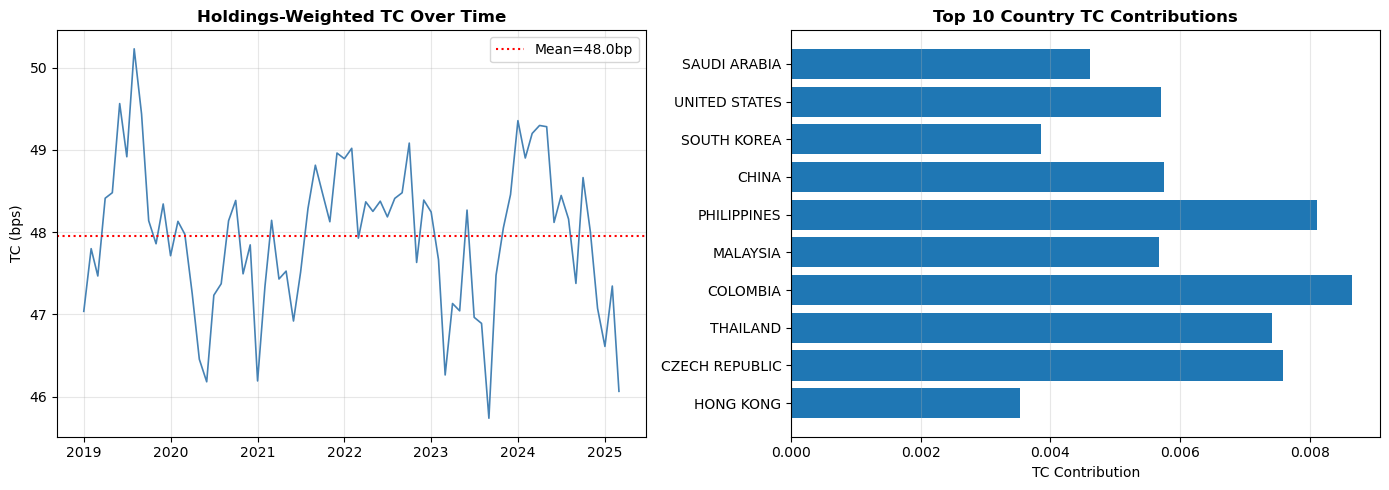

In [3]:
monthly_tc = oos.groupby('ym').apply(
    lambda g: pd.Series({
        'weighted_tc': (g['weight'] * g['tc_bps']).sum() / g['weight'].sum(),
        'n_stocks': len(g),
        'n_countries': g['country'].nunique(),
    }), include_groups=False
)

print(f'=== Dynamic Country-Weighted TC (bps) ===')
print(f'Holdings-weighted: mean={monthly_tc["weighted_tc"].mean():.1f}, '
      f'median={monthly_tc["weighted_tc"].median():.1f}, '
      f'min={monthly_tc["weighted_tc"].min():.1f}, '
      f'max={monthly_tc["weighted_tc"].max():.1f}')
print(f'Universe average (simple): {DEFAULT_TC_BPS} bps')

country_tc = oos.groupby('country').apply(
    lambda g: pd.Series({
        'Avg_Wt': g['weight'].mean(),
        'TC_bps': g['tc_bps'].iloc[0],
        'TC_Contrib': g['weight'].mean() * g['tc_bps'].iloc[0] / 100,
        'Months': g['ym'].nunique(),
    }), include_groups=False
).sort_values('Avg_Wt', ascending=False)

print(f'\n=== Country TC Contribution (Strategy Holdings) ===')
print(f'{"Country":30s} {"Avg Wt%":>8s} {"TC (bps)":>8s} {"TC Contrib":>10s} {"Months":>6s}')
print('-' * 70)
for c, row in country_tc.head(15).iterrows():
    print(f'{c:30s} {row["Avg_Wt"]:7.2%} {row["TC_bps"]:8.0f} {row["TC_Contrib"]:10.2f} {row["Months"]:6.0f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.plot(monthly_tc.index, monthly_tc['weighted_tc'].values, lw=1.2, color='steelblue')
ax.axhline(y=monthly_tc['weighted_tc'].mean(), color='red', ls=':',
           label=f'Mean={monthly_tc["weighted_tc"].mean():.1f}bp')
ax.set_title('Holdings-Weighted TC Over Time', fontweight='bold')
ax.set_ylabel('TC (bps)'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
top10 = country_tc.head(10)
ax.barh(top10.index, top10['TC_Contrib'])
ax.set_title('Top 10 Country TC Contributions', fontweight='bold')
ax.set_xlabel('TC Contribution'); ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/nb12_holdings_tc.pdf', bbox_inches='tight')
plt.show()

## 3. Time-Varying TC

EM trading costs have declined secularly. We model a 2.5% annual decay rate
from the 2001 Domowitz et al. estimates.

=== Time-Varying TC Model ===
Annual decay rate: 2.5%
Static TC (avg): 48.0 bps
Time-adjusted TC (avg): 28.5 bps
Reduction: 41%


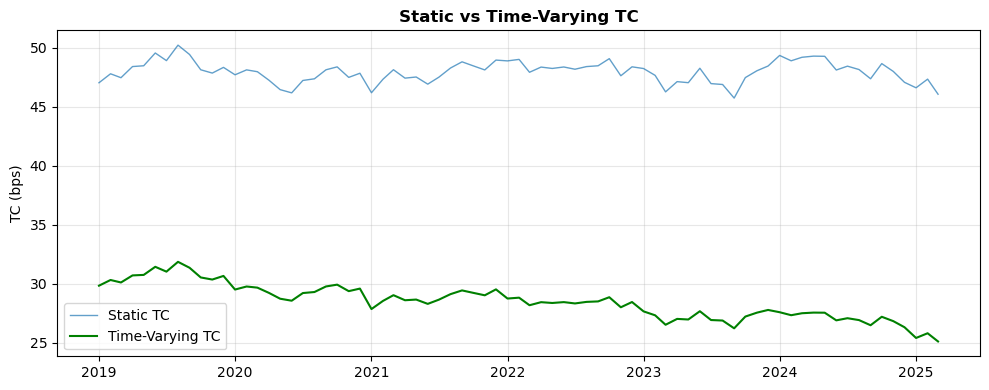

In [4]:
BASE_YEAR = 2001
DECAY_RATE = 0.025

monthly_tc['year'] = pd.to_datetime(monthly_tc.index).year
monthly_tc['decay'] = (1 - DECAY_RATE) ** (monthly_tc['year'] - BASE_YEAR)
monthly_tc['time_varying_tc'] = monthly_tc['weighted_tc'] * monthly_tc['decay']

print(f'=== Time-Varying TC Model ===')
print(f'Annual decay rate: {DECAY_RATE:.1%}')
print(f'Static TC (avg): {monthly_tc["weighted_tc"].mean():.1f} bps')
print(f'Time-adjusted TC (avg): {monthly_tc["time_varying_tc"].mean():.1f} bps')
print(f'Reduction: {(1 - monthly_tc["time_varying_tc"].mean()/monthly_tc["weighted_tc"].mean())*100:.0f}%')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly_tc.index, monthly_tc['weighted_tc'].values, lw=1, label='Static TC', alpha=0.7)
ax.plot(monthly_tc.index, monthly_tc['time_varying_tc'].values, lw=1.5, label='Time-Varying TC', color='green')
ax.set_title('Static vs Time-Varying TC', fontweight='bold')
ax.set_ylabel('TC (bps)'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/nb12_time_varying_tc.pdf', bbox_inches='tight')
plt.show()

## 3b. Performance Under Time-Varying TC

Apply the month-by-month time-varying TC to actual strategy returns to compute 
realized net performance. Compare three scenarios:
- **Gross**: No TC deduction (0 bps)
- **Static 45bp**: Uniform 45 bps applied to total turnover each month
- **Time-Varying**: Path-dependent TC using decayed country-weighted estimates

Turnover: TO_MVO=0.192/mo, Momentum=0.280/mo
PERFORMANCE UNDER DIFFERENT TC SCENARIOS: All6-EW + TO_MVO (Holdout 2019-2025)
            Scenario  LO Sharpe  Hedged SR   LO Ann Ret  Hedged Ann Ret
-------------------------------------------------------------------------------------
         Gross (0bp)      0.514      0.828       9.50%          5.52%
       Static (45bp)      0.458      0.673       8.46%          4.48%
        Time-Varying      0.479      0.729       8.84%          4.86%

PERFORMANCE UNDER DIFFERENT TC SCENARIOS: All6-EW + Momentum (Holdout 2019-2025)
            Scenario  LO Sharpe  Hedged SR   LO Ann Ret  Hedged Ann Ret
-------------------------------------------------------------------------------------
         Gross (0bp)      0.503      0.795       9.19%          5.23%
       Static (45bp)      0.421      0.565       7.67%          3.71%
        Time-Varying      0.451      0.649       8.23%          4.26%


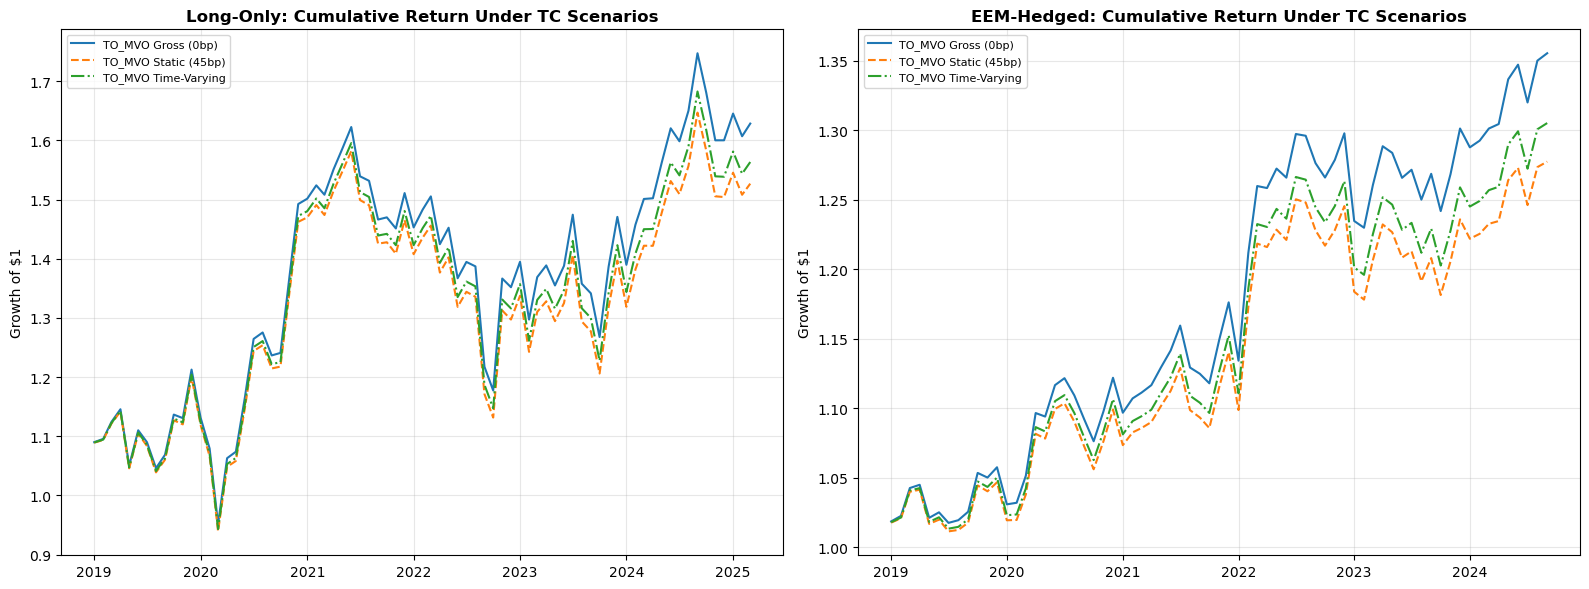


Time-varying TC in holdout period:
  Average: 28.5 bps
  Min: 25.1 bps, Max: 31.8 bps
  vs Static: 45.0 bps (conservative estimate)


In [5]:
# Compute turnover values (needed for TC drag calculation)
_sto_df = pd.read_csv(f'{OUTPUT_DIR}/csv/exp3b_turnovers.csv', index_col=0)
_mc = pd.read_csv(f'{OUTPUT_DIR}/csv/exp4_multicriteria_scores.csv')
_stock_to = _sto_df.loc['All6-EW', 'avg_monthly_turnover']
_pc_mvo, _pc_mom = 0.007, 0.096
for _, _row in _mc.iterrows():
    if 'All6EW' in _row['Strategy']:
        if _row['PC'] == 'TO_MVO': _pc_mvo = _row['PC_TO']
        if _row['PC'] == 'Momentum': _pc_mom = _row['PC_TO']
total_mvo = _stock_to + _pc_mvo
total_mom = _stock_to + _pc_mom
print(f'Turnover: TO_MVO={total_mvo:.3f}/mo, Momentum={total_mom:.3f}/mo')

# Load returns and compute holdout period
lo_tv = hdf['A_long'].dropna()
hd_tv = hdf['A_hedged_eem'].dropna()
lo_h_tv = lo_tv[lo_tv.index >= HOLD_START]
hd_h_tv = hd_tv[hd_tv.index >= HOLD_START]

# Also load momentum for comparison
lo_mom_tv = hdf['B_long'].dropna()
hd_mom_tv = hdf['B_hedged_eem'].dropna()
lo_mom_h_tv = lo_mom_tv[lo_mom_tv.index >= HOLD_START]
hd_mom_h_tv = hd_mom_tv[hd_mom_tv.index >= HOLD_START]

# Align time-varying TC with return indices
# monthly_tc is indexed by ym strings; convert to timestamps
tv_tc = monthly_tc['time_varying_tc'].copy()
tv_tc.index = pd.to_datetime(tv_tc.index)

# Build monthly TC drag: time_varying_tc (bps) * total_turnover / 10000
tv_drag_mvo = (tv_tc.reindex(lo_h_tv.index, method='nearest') * total_mvo / 10000).fillna(0)
tv_drag_mom = (tv_tc.reindex(lo_mom_h_tv.index, method='nearest') * total_mom / 10000).fillna(0)

# Static 45bp drag
static_drag_mvo = total_mvo * 45 / 10000
static_drag_mom = total_mom * 45 / 10000

# Compute net returns for TO_MVO
scenarios_mvo = {
    'Gross (0bp)': {'lo': lo_h_tv, 'hd': hd_h_tv},
    'Static (45bp)': {'lo': lo_h_tv - static_drag_mvo, 'hd': hd_h_tv - static_drag_mvo},
    'Time-Varying': {'lo': lo_h_tv - tv_drag_mvo, 'hd': hd_h_tv - tv_drag_mvo},
}

# Print comparison table
print('=' * 85)
print('PERFORMANCE UNDER DIFFERENT TC SCENARIOS: All6-EW + TO_MVO (Holdout 2019-2025)')
print('=' * 85)
print(f'{"Scenario":>20s} {"LO Sharpe":>10s} {"Hedged SR":>10s} {"LO Ann Ret":>12s} {"Hedged Ann Ret":>15s}')
print('-' * 85)

results = []
for name, d in scenarios_mvo.items():
    lo_sr = ann_sharpe(d['lo'])
    hd_sr = ann_sharpe(d['hd'])
    lo_ret = d['lo'].mean() * 12
    hd_ret = d['hd'].mean() * 12
    print(f'{name:>20s} {lo_sr:10.3f} {hd_sr:10.3f} {lo_ret:11.2%} {hd_ret:14.2%}')
    results.append({
        'Strategy': 'TO_MVO', 'Scenario': name,
        'LO_Sharpe': lo_sr, 'Hedged_Sharpe': hd_sr,
        'LO_Ann_Ret': lo_ret, 'Hedged_Ann_Ret': hd_ret,
    })

# Also compute for Momentum
scenarios_mom = {
    'Gross (0bp)': {'lo': lo_mom_h_tv, 'hd': hd_mom_h_tv},
    'Static (45bp)': {'lo': lo_mom_h_tv - static_drag_mom, 'hd': hd_mom_h_tv - static_drag_mom},
    'Time-Varying': {'lo': lo_mom_h_tv - tv_drag_mom, 'hd': hd_mom_h_tv - tv_drag_mom},
}

print()
print('=' * 85)
print('PERFORMANCE UNDER DIFFERENT TC SCENARIOS: All6-EW + Momentum (Holdout 2019-2025)')
print('=' * 85)
print(f'{"Scenario":>20s} {"LO Sharpe":>10s} {"Hedged SR":>10s} {"LO Ann Ret":>12s} {"Hedged Ann Ret":>15s}')
print('-' * 85)

for name, d in scenarios_mom.items():
    lo_sr = ann_sharpe(d['lo'])
    hd_sr = ann_sharpe(d['hd'])
    lo_ret = d['lo'].mean() * 12
    hd_ret = d['hd'].mean() * 12
    print(f'{name:>20s} {lo_sr:10.3f} {hd_sr:10.3f} {lo_ret:11.2%} {hd_ret:14.2%}')
    results.append({
        'Strategy': 'Momentum', 'Scenario': name,
        'LO_Sharpe': lo_sr, 'Hedged_Sharpe': hd_sr,
        'LO_Ann_Ret': lo_ret, 'Hedged_Ann_Ret': hd_ret,
    })

# Save CSV
pd.DataFrame(results).to_csv(f'{OUTPUT_DIR}/csv/nb12_time_varying_tc_performance.csv', index=False)

# Plot cumulative returns under 3 scenarios
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Long-Only
ax = axes[0]
for name, d in scenarios_mvo.items():
    cum = (1 + d['lo']).cumprod()
    ls = '-' if name == 'Gross (0bp)' else ('--' if name == 'Static (45bp)' else '-.')
    ax.plot(cum.index, cum.values, lw=1.5, ls=ls, label=f'TO_MVO {name}')
ax.set_title('Long-Only: Cumulative Return Under TC Scenarios', fontweight='bold')
ax.set_ylabel('Growth of $1')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Hedged
ax = axes[1]
for name, d in scenarios_mvo.items():
    cum = (1 + d['hd']).cumprod()
    ls = '-' if name == 'Gross (0bp)' else ('--' if name == 'Static (45bp)' else '-.')
    ax.plot(cum.index, cum.values, lw=1.5, ls=ls, label=f'TO_MVO {name}')
ax.set_title('EEM-Hedged: Cumulative Return Under TC Scenarios', fontweight='bold')
ax.set_ylabel('Growth of $1')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/nb12_time_varying_performance.pdf', bbox_inches='tight')
plt.show()

print(f'\nTime-varying TC in holdout period:')
tv_holdout = tv_tc[tv_tc.index >= HOLD_START]
print(f'  Average: {tv_holdout.mean():.1f} bps')
print(f'  Min: {tv_holdout.min():.1f} bps, Max: {tv_holdout.max():.1f} bps')
print(f'  vs Static: 45.0 bps (conservative estimate)')

## 4. TC Decomposition

=== TC Decomposition by Country ===
Typical split: Commission 35%, Bid-Ask Spread 45%, Market Impact 20%

                    TC_bps  Avg_Wt  Commission  Spread  Impact
country                                                       
HONG KONG             20.0  0.0176         7.0     9.0     4.0
CZECH REPUBLIC        45.0  0.0169        15.7    20.2     9.0
THAILAND              45.0  0.0165        15.7    20.2     9.0
COLOMBIA              60.0  0.0144        21.0    27.0    12.0
MALAYSIA              40.0  0.0142        14.0    18.0     8.0
PHILIPPINES           70.0  0.0116        24.5    31.5    14.0
CHINA                 50.0  0.0115        17.5    22.5    10.0
SOUTH KOREA           35.0  0.0110        12.2    15.8     7.0
UNITED STATES         55.0  0.0104        19.2    24.8    11.0
SAUDI ARABIA          45.0  0.0102        15.7    20.2     9.0
INDIA                 50.0  0.0101        17.5    22.5    10.0
UNITED KINGDOM        55.0  0.0099        19.2    24.8    11.0
NETHERLANDS 

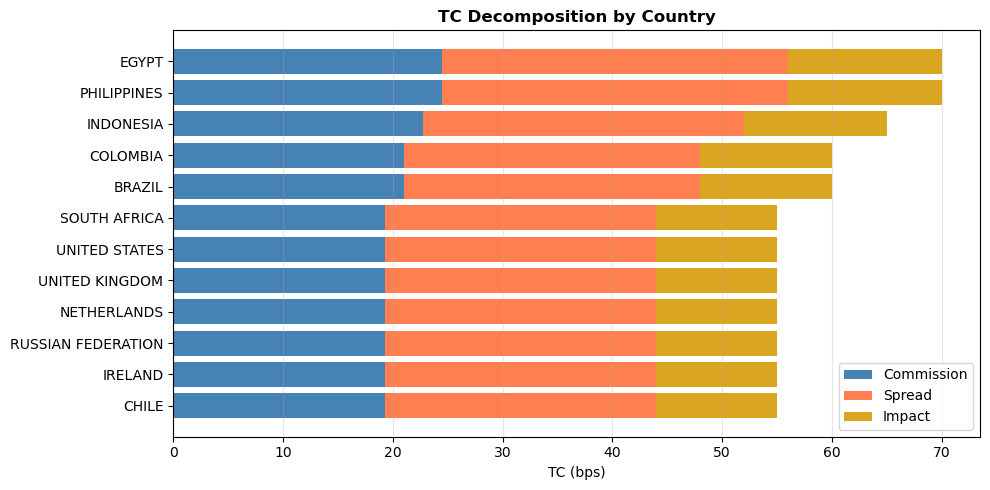

In [6]:
print('=== TC Decomposition by Country ===')
print('Typical split: Commission 35%, Bid-Ask Spread 45%, Market Impact 20%')
print()

decomp = country_tc[['TC_bps','Avg_Wt']].copy()
decomp['Commission'] = decomp['TC_bps'] * 0.35
decomp['Spread'] = decomp['TC_bps'] * 0.45
decomp['Impact'] = decomp['TC_bps'] * 0.20

print(decomp.head(15).to_string(float_format=lambda x: f'{x:.1f}' if x>1 else f'{x:.4f}'))

wt_avg_tc = (country_tc['Avg_Wt'] * country_tc['TC_bps']).sum() / country_tc['Avg_Wt'].sum()
print(f'\nPortfolio-weighted average TC: {wt_avg_tc:.1f} bps')
print(f'  Commission: {wt_avg_tc*0.35:.1f} bps')
print(f'  Bid-Ask Spread: {wt_avg_tc*0.45:.1f} bps')
print(f'  Market Impact: {wt_avg_tc*0.20:.1f} bps')

fig, ax = plt.subplots(figsize=(10, 5))
top = decomp.sort_values('TC_bps', ascending=True).tail(12)
ax.barh(top.index, top['Commission'], label='Commission', color='steelblue')
ax.barh(top.index, top['Spread'], left=top['Commission'], label='Spread', color='coral')
ax.barh(top.index, top['Impact'], left=top['Commission']+top['Spread'],
        label='Impact', color='goldenrod')
ax.set_title('TC Decomposition by Country', fontweight='bold')
ax.set_xlabel('TC (bps)'); ax.legend(); ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/nb12_tc_decomposition.pdf', bbox_inches='tight')
plt.show()

## 5. Turnover Decomposition: TO\_MVO vs Momentum

=== Turnover Decomposition ===
                            Stock TO      PC TO   Total TO     Annual
----------------------------------------------------------------------
All6-EW + TO_MVO               0.184      0.007      0.192       2.3x
All6-EW + Momentum             0.184      0.096      0.280       3.4x

  TO_MVO saves 32% turnover vs Momentum
  This is the built-in turnover penalty in TO_MVO's objective function.

=== DOLLAR TRADING & TC COST (At 45bp) ===
  AUM ($M)    TO_MVO Trade    TO_MVO TC       Mom Trade       Mom TC    Savings
      50M           9.6M       0.04M/mo          14.0M       0.06M/mo      0.2M/yr
     100M          19.2M       0.09M/mo          28.0M       0.13M/mo      0.5M/yr
     200M          38.3M       0.17M/mo          56.0M       0.25M/mo      1.0M/yr
     500M          95.8M       0.43M/mo         140.1M       0.63M/mo      2.4M/yr
    1000M         191.6M       0.86M/mo         280.1M       1.26M/mo      4.8M/yr


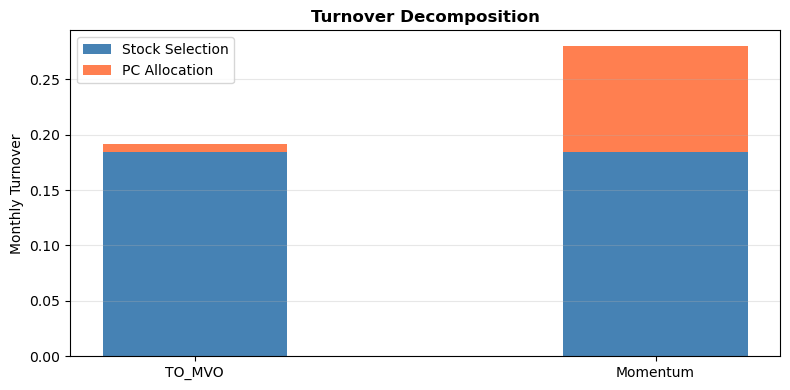

In [7]:
stock_to_df = pd.read_csv(f'{OUTPUT_DIR}/csv/exp3b_turnovers.csv', index_col=0)
mc_scores = pd.read_csv(f'{OUTPUT_DIR}/csv/exp4_multicriteria_scores.csv')

stock_to = stock_to_df.loc['All6-EW', 'avg_monthly_turnover']
pc_to_mvo, pc_to_mom = 0.007, 0.096
for _, row in mc_scores.iterrows():
    if 'All6EW' in row['Strategy']:
        if row['PC'] == 'TO_MVO': pc_to_mvo = row['PC_TO']
        if row['PC'] == 'Momentum': pc_to_mom = row['PC_TO']

total_mvo = stock_to + pc_to_mvo
total_mom = stock_to + pc_to_mom

print('=== Turnover Decomposition ===')
print(f'{"":25s} {"Stock TO":>10s} {"PC TO":>10s} {"Total TO":>10s} {"Annual":>10s}')
print('-'*70)
print(f'{"All6-EW + TO_MVO":25s} {stock_to:10.3f} {pc_to_mvo:10.3f} {total_mvo:10.3f} {total_mvo*12:9.1f}x')
print(f'{"All6-EW + Momentum":25s} {stock_to:10.3f} {pc_to_mom:10.3f} {total_mom:10.3f} {total_mom*12:9.1f}x')
print(f'\n  TO_MVO saves {(total_mom-total_mvo)/total_mom*100:.0f}% turnover vs Momentum')
print(f'  This is the built-in turnover penalty in TO_MVO\'s objective function.')

# Dollar trading & TC examples
print(f'\n=== DOLLAR TRADING & TC COST (At 45bp) ===')
print(f'{"AUM ($M)":>10s} {"TO_MVO Trade":>15s} {"TO_MVO TC":>12s} {"Mom Trade":>15s} {"Mom TC":>12s} {"Savings":>10s}')
for aum in [50, 100, 200, 500, 1000]:
    trade_mvo = aum * total_mvo
    trade_mom = aum * total_mom
    tc_mvo = trade_mvo * 45 / 10000
    tc_mom = trade_mom * 45 / 10000
    sav = (tc_mom - tc_mvo) * 12
    print(f'{aum:>8d}M {trade_mvo:>13.1f}M {tc_mvo:>10.2f}M/mo {trade_mom:>13.1f}M {tc_mom:>10.2f}M/mo {sav:>8.1f}M/yr')

fig, ax = plt.subplots(figsize=(8, 4))
labels = ['TO_MVO', 'Momentum']
x = np.arange(2)
ax.bar(x, [stock_to, stock_to], 0.4, label='Stock Selection', color='steelblue')
ax.bar(x, [pc_to_mvo, pc_to_mom], 0.4, bottom=[stock_to, stock_to],
       label='PC Allocation', color='coral')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Monthly Turnover'); ax.set_title('Turnover Decomposition', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/nb12_turnover.pdf', bbox_inches='tight')
plt.show()

## 6. Gradual Sharpe Loss Under Varying TC

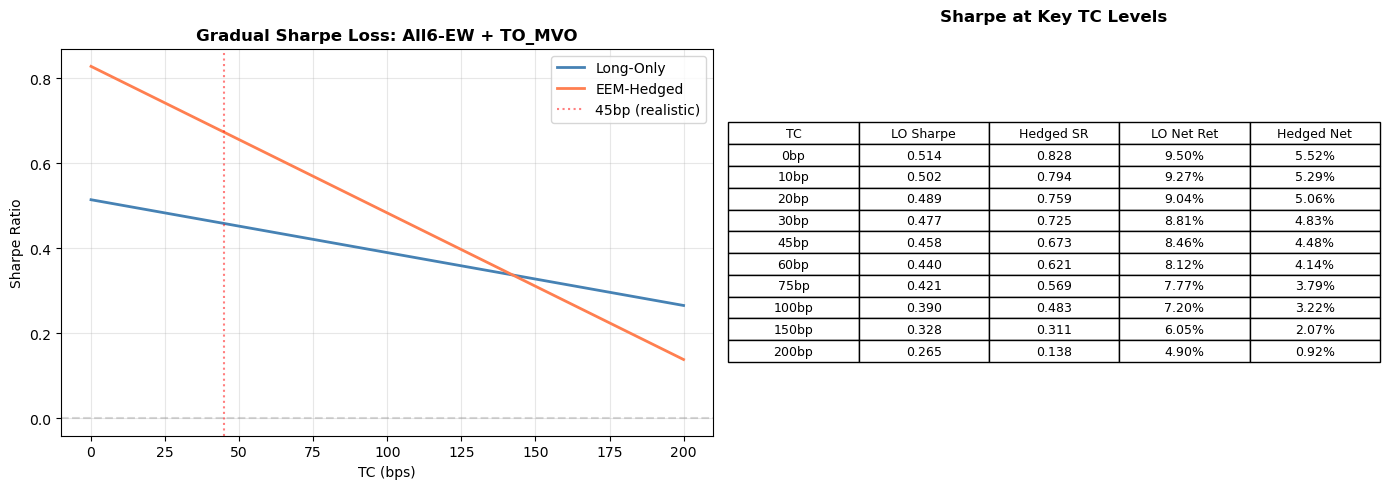

SHARPE DEGRADATION TABLE: All6-EW + TO_MVO (Holdout)
    TC  LO Sharpe  Hedged SR   LO Net Ret   Hedged Net
   0bp      0.514      0.828       9.50%       5.52%
  10bp      0.502      0.794       9.27%       5.29%
  20bp      0.489      0.759       9.04%       5.06%
  30bp      0.477      0.725       8.81%       4.83%
  45bp      0.458      0.673       8.46%       4.48%
  60bp      0.440      0.621       8.12%       4.14%
  75bp      0.421      0.569       7.77%       3.79%
 100bp      0.390      0.483       7.20%       3.22%
 150bp      0.328      0.311       6.05%       2.07%
 200bp      0.265      0.138       4.90%       0.92%


In [8]:
lo = hdf['A_long'].dropna()
hd = hdf['A_hedged_eem'].dropna()
lo_h = lo[lo.index >= HOLD_START]
hd_h = hd[hd.index >= HOLD_START]

key_tc = [0, 10, 20, 30, 45, 60, 75, 100, 150, 200]
tc_range = np.arange(0, 201, 2)

lo_sharpes_full = [ann_sharpe(lo_h - total_mvo*(t/10000)) for t in tc_range]
hd_sharpes_full = [ann_sharpe(hd_h - total_mvo*(t/10000)) for t in tc_range]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(tc_range, lo_sharpes_full, lw=2, color='steelblue', label='Long-Only')
ax.plot(tc_range, hd_sharpes_full, lw=2, color='coral', label='EEM-Hedged')
ax.axvline(x=45, color='red', ls=':', alpha=0.5, label='45bp (realistic)')
ax.axhline(y=0, color='gray', ls='--', alpha=0.3)
ax.set_xlabel('TC (bps)'); ax.set_ylabel('Sharpe Ratio')
ax.set_title('Gradual Sharpe Loss: All6-EW + TO_MVO', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.axis('off')
table_data = []
for tc in key_tc:
    drag = total_mvo * (tc / 10000)
    table_data.append([
        f'{tc}bp',
        f'{ann_sharpe(lo_h - drag):.3f}',
        f'{ann_sharpe(hd_h - drag):.3f}',
        f'{(lo_h - drag).mean()*12:.2%}',
        f'{(hd_h - drag).mean()*12:.2%}',
    ])
table = ax.table(cellText=table_data,
                  colLabels=['TC', 'LO Sharpe', 'Hedged SR', 'LO Net Ret', 'Hedged Net'],
                  loc='center', cellLoc='center')
table.auto_set_font_size(False); table.set_fontsize(9); table.scale(1, 1.3)
ax.set_title('Sharpe at Key TC Levels', fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/nb12_gradual_loss.pdf', bbox_inches='tight')
plt.show()

print('SHARPE DEGRADATION TABLE: All6-EW + TO_MVO (Holdout)')
print('='*80)
print(f'{"TC":>6s} {"LO Sharpe":>10s} {"Hedged SR":>10s} {"LO Net Ret":>12s} {"Hedged Net":>12s}')
for tc in key_tc:
    drag = total_mvo * (tc / 10000)
    print(f'{tc:>4d}bp {ann_sharpe(lo_h-drag):10.3f} {ann_sharpe(hd_h-drag):10.3f} '
          f'{(lo_h-drag).mean()*12:11.2%} {(hd_h-drag).mean()*12:11.2%}')

## 7. Break-Even Analysis & Scenarios

In [9]:
print('BREAK-EVEN TC (All6-EW + TO_MVO, Holdout)')
print('='*60)
for target in [0.5, 0.3, 0.0]:
    lo_be, hd_be = None, None
    for tc in range(0, 2000):
        drag = total_mvo * (tc / 10000)
        if lo_be is None and ann_sharpe(lo_h - drag) <= target:
            lo_be = tc
        if hd_be is None and ann_sharpe(hd_h - drag) <= target:
            hd_be = tc
    print(f'  Sharpe={target:.1f}: Long-Only BE={lo_be or ">2000"}bp, Hedged BE={hd_be or ">2000"}bp')

print(f'\n=== TC SCENARIO ANALYSIS ===')
scenarios = [
    ('Optimistic (2024 adj.)', 0.6),
    ('Base Case (Domowitz)', 1.0),
    ('Conservative', 1.3),
    ('Stress', 2.0),
]
for name, mult in scenarios:
    eff_tc_bps = 45 * mult
    drag = total_mvo * (eff_tc_bps / 10000)
    lo_sr = ann_sharpe(lo_h - drag)
    hd_sr = ann_sharpe(hd_h - drag)
    print(f'  {name:25s}: TC={eff_tc_bps:5.0f}bp → LO SR={lo_sr:.3f}, Hedged SR={hd_sr:.3f}, '
          f'LO Net={((lo_h-drag).mean()*12):.2%}')

# Save
pd.DataFrame({
    'TC_bps': key_tc,
    'LO_Sharpe': [ann_sharpe(lo_h - total_mvo*(tc/10000)) for tc in key_tc],
    'Hedged_Sharpe': [ann_sharpe(hd_h - total_mvo*(tc/10000)) for tc in key_tc],
    'LO_Net_Ret': [(lo_h - total_mvo*(tc/10000)).mean()*12 for tc in key_tc],
    'Hedged_Net_Ret': [(hd_h - total_mvo*(tc/10000)).mean()*12 for tc in key_tc],
}).to_csv(f'{OUTPUT_DIR}/csv/nb12_sharpe_degradation.csv', index=False)
print(f'\nSaved results to {OUTPUT_DIR}/csv/')

BREAK-EVEN TC (All6-EW + TO_MVO, Holdout)
  Sharpe=0.5: Long-Only BE=12bp, Hedged BE=96bp
  Sharpe=0.3: Long-Only BE=173bp, Hedged BE=154bp
  Sharpe=0.0: Long-Only BE=414bp, Hedged BE=240bp

=== TC SCENARIO ANALYSIS ===
  Optimistic (2024 adj.)   : TC=   27bp → LO SR=0.481, Hedged SR=0.735, LO Net=8.88%
  Base Case (Domowitz)     : TC=   45bp → LO SR=0.458, Hedged SR=0.673, LO Net=8.46%
  Conservative             : TC=   58bp → LO SR=0.441, Hedged SR=0.626, LO Net=8.15%
  Stress                   : TC=   90bp → LO SR=0.402, Hedged SR=0.518, LO Net=7.43%

Saved results to ../output/csv/


## Hedge Instrument Deep Dive and Country TC Estimates


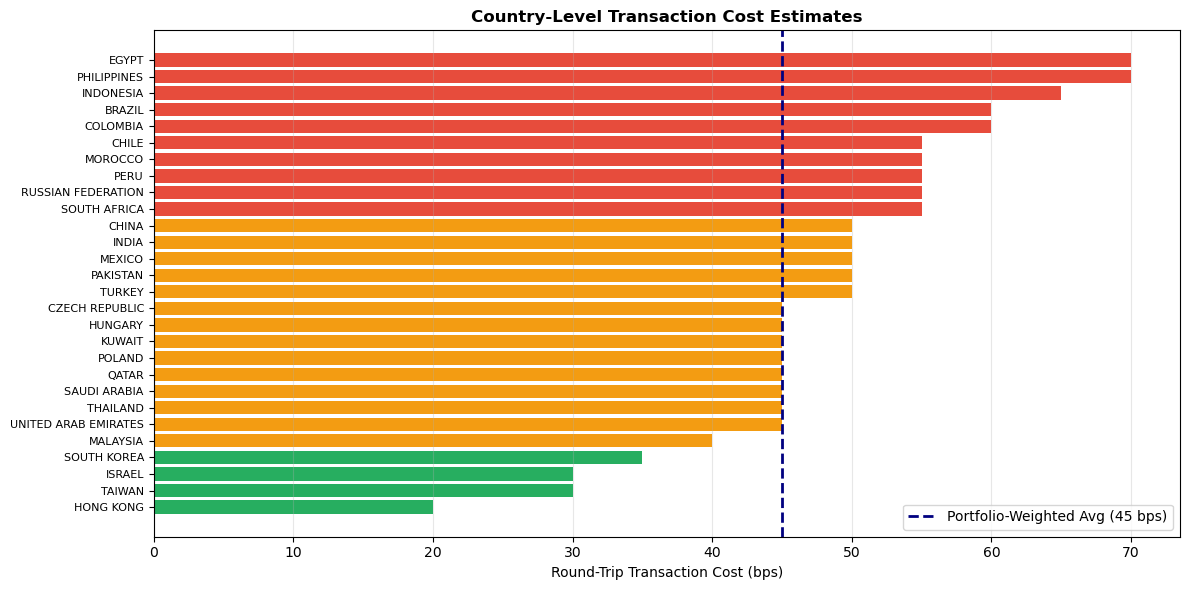

In [10]:
# Country TC bar chart
from src.data_loader import COUNTRY_TC_BPS, DEFAULT_TC_BPS

tc_df = pd.DataFrame([
    {'Country': k, 'TC (bps)': v}
    for k, v in sorted(COUNTRY_TC_BPS.items(), key=lambda x: -x[1])
])

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#e74c3c' if v > 50 else '#f39c12' if v > 35 else '#27ae60' for v in tc_df['TC (bps)']]
ax.barh(range(len(tc_df)), tc_df['TC (bps)'], color=colors)
ax.set_yticks(range(len(tc_df)))
ax.set_yticklabels(tc_df['Country'], fontsize=8)
ax.set_xlabel('Round-Trip Transaction Cost (bps)')
ax.set_title('Country-Level Transaction Cost Estimates', fontweight='bold')
ax.axvline(45, color='navy', ls='--', lw=2, label=f'Portfolio-Weighted Avg (45 bps)')
ax.legend()
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/country_tc_estimates.pdf', bbox_inches='tight')
plt.show()


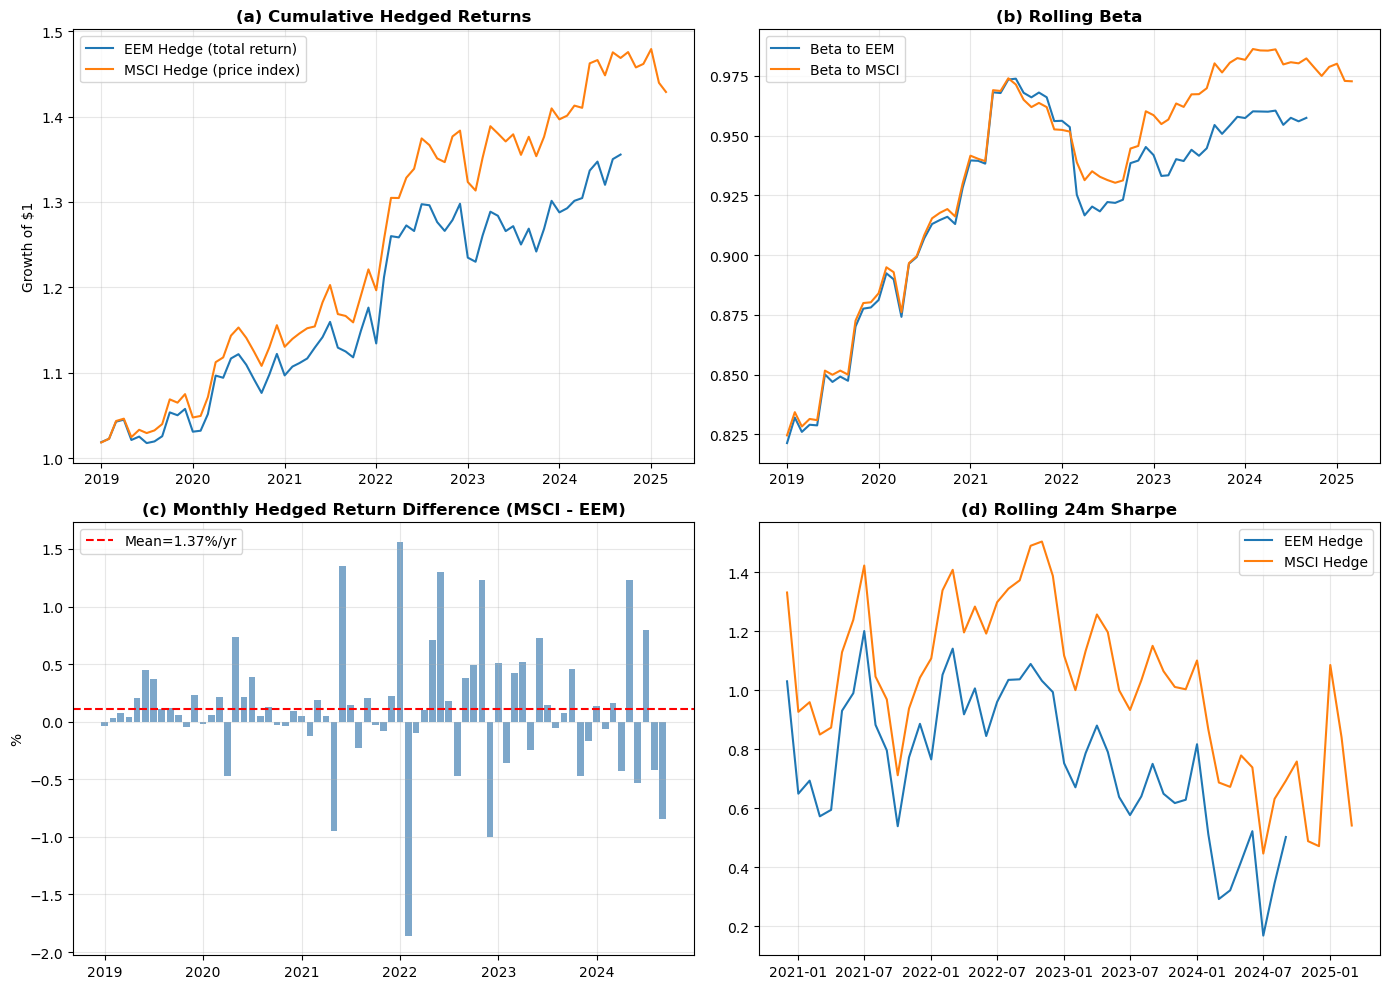

In [11]:
# Hedge instrument deep dive: EEM vs MSCI EM price index
hdf = pd.read_csv(f'{OUTPUT_DIR}/csv/nb09_hedged_returns.csv', index_col=0, parse_dates=True)
holdout = hdf[hdf.index >= '2019-01'].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) Cumulative hedged returns: EEM vs MSCI
ax = axes[0,0]
ax.plot((1+holdout['A_hedged_eem']).cumprod(), label='EEM Hedge (total return)', lw=1.5)
ax.plot((1+holdout['A_hedged_msci']).cumprod(), label='MSCI Hedge (price index)', lw=1.5)
ax.set_title('(a) Cumulative Hedged Returns', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_ylabel('Growth of $1')

# (b) Rolling betas
ax = axes[0,1]
ax.plot(holdout['A_beta_eem'], label='Beta to EEM', lw=1.5)
ax.plot(holdout['A_beta_msci'], label='Beta to MSCI', lw=1.5)
ax.set_title('(b) Rolling Beta', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)

# (c) Monthly return difference
ax = axes[1,0]
diff = holdout['A_hedged_msci'] - holdout['A_hedged_eem']
ax.bar(diff.index, diff.values*100, width=25, alpha=0.7, color='steelblue')
ax.axhline(diff.mean()*100, color='red', ls='--', label=f'Mean={diff.mean()*1200:.2f}%/yr')
ax.set_title('(c) Monthly Hedged Return Difference (MSCI - EEM)', fontweight='bold')
ax.set_ylabel('%'); ax.legend(); ax.grid(True, alpha=0.3)

# (d) Rolling Sharpe comparison
ax = axes[1,1]
for col, label in [('A_hedged_eem','EEM Hedge'), ('A_hedged_msci','MSCI Hedge')]:
    roll_sr = holdout[col].rolling(24).apply(lambda s: s.mean()*12/(s.std()*np.sqrt(12)) if s.std()>0 else 0)
    ax.plot(roll_sr, label=label, lw=1.5)
ax.set_title('(d) Rolling 24m Sharpe', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/nb12_hedge_deep_dive.pdf', bbox_inches='tight')
plt.show()
